In [ ]:
#import libraries
import requests
import pandas as pd
import numpy as np
import csv
import urllib.request
from bs4 import BeautifulSoup

In [ ]:
df = pd.read_csv('data_appartments.tsv',sep='\t')

In [ ]:
df.head()

,title,price,space,district,location,built_year,leasing,floor,building_max_floor,city,published,id
0,Худ 11 хороо river plaza- д 4 өрөө орон сууц 1...,960 сая ₮ ...,139.00,Хан-Уул,River Garden,2022,Лизинггүй,13,24,Улаанбаатар,2022-03-26 11:17,5722020
1,3 өрөө байр 68м2,"2,9 сая ₮",68.00,Баянгол,Төмөр зам,2012,Лизинггүй,6,9,Улаанбаатар,2022-03-02 17:02,5810062
2,Жаст хотхон 2 өрөө байр 56.7м2,158 сая ₮ ...,56.70,Баянзүрх,14-р хороолол,2015,Банкны лизингтэй,8,15,Улаанбаатар,2022-03-16 17:26,5858883
3,"Цирк, ub central residence д 3 өрөө байр",466 сая ₮ ...,108.00,Сүхбаатар,220 мянгат,2019,Лизинггүй,3,16,Улаанбаатар,2022-02-28 10:38,5714522
4,Хотын төв 4 өрөө спортын төв ордны зүүн талд,"366,3 сая ₮ ...",111.00,Сүхбаатар,Бага тойрог,2009,Банкны лизингтэй,9,10,Улаанбаатар,2022-03-04 17:22,5817231
5,Өргөөгийн яг баруун талын угсармалд 1 өрөө байр,95 сая ₮ ...,40.00,Баянгол,"3, 4 хороолол",1999,Лизинггүй,3,9,Улаанбаатар,2022-03-01 11:44,5804629
6,Kh apartment хажууд 79м2 3 өрөө байр,"4,3 сая ₮ ...",79.00,Хан-Уул,120 мянгат,2022,Лизинггүй,15,16,Улаанбаатар,2022-03-25 9:04,5887649
7,3-р эмнэлгийн замын урд 31m2 1өрөө,78 сая ₮ ...,31.00,Баянгол,10-р хороолол,2012,Лизинггүй,4,5,Улаанбаатар,2022-03-14 12:41,5692382
8,100 айлд цэвэрхэн 2 өрөө орон сууц,110 сая ₮,44.34,Сүхбаатар,Бусад,2016,Лизинггүй,7,12,Улаанбаатар,2022-03-24 14:50,5885551
9,Гарден сити-2 95.80 м2 4 өрөө,"431,1 сая ₮",95.80,Хан-Уул,Яармаг,2022,Лизинггүй,9,16,Улаанбаатар,2022-03-17 10:35,5744368


In [ ]:
filtered_df = df[df.city == 'Улаанбаатар']

print(len(df),len(filtered_df))

for index, row in filtered_df.iterrows():
  if ('сая ₮' in row['price']) is False:
    print(row)


7002 6959
title                 Жардин хотхонд 4 өрөө байр 190м2
price                                     1,4 Тэрбум ₮
space                                            190.0
district                                       Хан-Уул
location                                        Зайсан
built_year                                        2017
leasing                                      Лизинггүй
floor                                                4
building_max_floor                                   6
city                                       Улаанбаатар
published                             2022-03-08 10:29
id                                             5764451
Name: 43, dtype: object
title                               220k residence 4 өрөө байр 141.87м2
price                 1,05 Тэрбум ₮                                 ...
space                                                            141.87
district                                                      Сүхбаатар
location          

In [ ]:
def extractTprice(price):
  ans = .0
  if 'сая ₮' in price:
    ans = float(price.split('сая ₮')[0].strip().replace(',','.'))
  elif 'Тэрбум ₮' in price:
    ans = float(price.split('Тэрбум ₮')[0].strip().replace(',','.')) * 1000
  else:
    return None
  return ans


def normalizeDataSet(app_set):
  ret = pd.DataFrame(columns=["total","m2_price",'space','district','title','year','floor', 'leasing'])
  for index, row in app_set.iterrows():
    t_price = extractTprice(row['price'])
    if t_price is None:
      continue
    if float(row['space']) < 10 or float(row['space']) > 200:
      continue
    #print(float(row['space']))
    if row['leasing'].strip()=='Лизинггүй':
      leas = False
    else:
      leas = True
    if float(t_price) > 21:
      total = float(t_price)
      m2 = t_price / float(row['space'])
    else:
      total = float(t_price * float(row['space']))
      m2 = float(t_price)
    if m2 > 10:
      continue
    ret = ret.append({'total': total, 'm2_price':m2,
                        'space': float(row['space']), 'floor': row['floor'], 'leasing' : leas,
                  'district': row['district'],'title': row['title'], 'year': row['built_year']}, ignore_index=True)
  return ret

In [ ]:
app_df = normalizeDataSet(filtered_df)

In [ ]:
len(app_df)

6843

In [ ]:
app_df.to_csv('data.csv')

In [ ]:
app_df.head()

,total,m2_price,space,district,title,year,floor,leasing
0,960.0,6.906475,139.0,Хан-Уул,Худ 11 хороо river plaza- д 4 өрөө орон сууц 1...,2022,13,False
1,197.2,2.900000,68.0,Баянгол,3 өрөө байр 68м2,2012,6,False
2,158.0,2.786596,56.7,Баянзүрх,Жаст хотхон 2 өрөө байр 56.7м2,2015,8,True
3,466.0,4.314815,108.0,Сүхбаатар,"Цирк, ub central residence д 3 өрөө байр",2019,3,False
4,366.3,3.300000,111.0,Сүхбаатар,Хотын төв 4 өрөө спортын төв ордны зүүн талд,2009,9,True


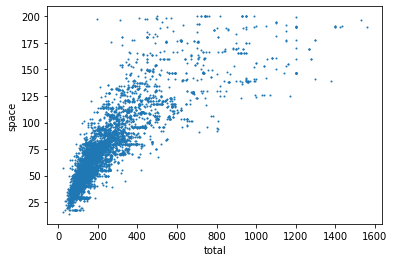

In [ ]:
app_df.plot.scatter(x = 'total', y = 'space', s = 1)

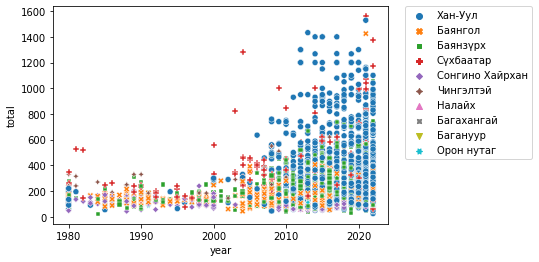

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(data=app_df, x="year", y="total", hue="district",style="district")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

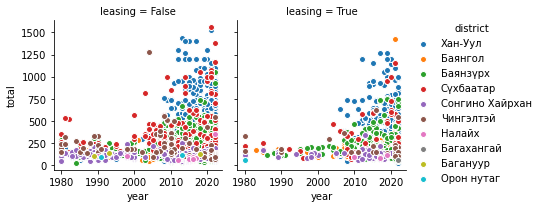

In [ ]:
graph = sns.FacetGrid(app_df, col ="leasing",  hue ="district")
# map the above form facetgrid with some attributes
graph.map(plt.scatter, "year", "total", edgecolor ="w").add_legend()
# show the object
plt.show()

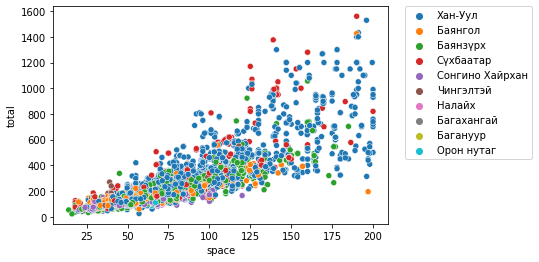

In [ ]:
sns.scatterplot(data=app_df, x="space", y="total", hue="district")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

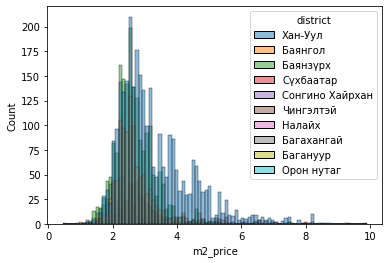

In [ ]:
sns.histplot(data=app_df, x="m2_price", hue="district")

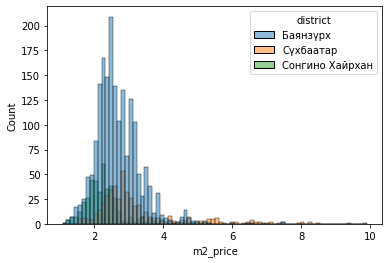

In [ ]:
df1 = app_df [(app_df.district == 'Сонгино Хайрхан') | (app_df.district == 'Сүхбаатар') |  (app_df.district == 'Баянзүрх')]

sns.histplot(data=df1, x="m2_price", hue="district")

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)


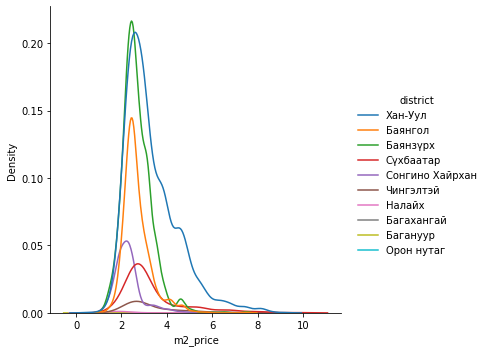

In [ ]:
sns.displot(data=app_df, x="m2_price", hue="district", kind='kde')

In [ ]:
from sentence_transformers import SentenceTransformer
sen_model = SentenceTransformer('joeddav/xlm-roberta-large-xnli')

Some weights of the model checkpoint at /root/.cache/torch/sentence_transformers/joeddav_xlm-roberta-large-xnli were not used when initializing XLMRobertaModel: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
- This IS expected if you are initializing XLMRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
sentences = []
y = []
z = []
for index, row in app_df.iterrows():
  sentences.append(row['title']+' '+row['district'])
  z.append(row['space'])
  y.append(row['total'])

In [ ]:
sentence_vectors = sen_model.encode(sentences)

In [ ]:
it = 0
x_ = []
for i in range(len(sentence_vectors)):
  B = np.array([z[it]])
  # B 1 x 1
  # Concat sentence vector with m2 value
  O = np.append(sentence_vectors[i], B)
  # O 1 x 100 + 1 x 1 = 1 x 101
  x_.append(O)
  it+=1

# x_ 5000 x 101
# y  5000 x 1

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)

model.fit(x_, y)

LinearRegression()

In [ ]:
# "River garden 60 м2 2 өрөө","11 хороолол 3 өрөө байр 70м2"
def extractSpace(sentence):
  ans = int(sum(z)/len(z))
  if 'м2' in sentence or 'm2' in sentence:
    sentence = sentence.replace('m2','м2')
    sentence = sentence.replace(' м2','м2')
    tokens = sentence.split(' ')
    for token in tokens:
      if token.endswith('м2') and len(token) > 2:
          ans = int(token[:len(token)-2])
          return ans
  return ans

def predictEstimate(sentence):
  p_embeddings = sen_model.encode([sentence])
  d = [extractSpace(sentence)]
  p_ = []
  for emb in p_embeddings:
    B = [d[0]]
    p_.append(np.append( emb , B ))
  y_prediction =  model.predict(p_)
  return y_prediction[0]

In [ ]:
print(predictEstimate("Hunnu 2222 50м2 2-өрөө"))
print(predictEstimate("Баянмонгол хороолол 74м2"))

218.848057909403
92.1373280310072
